In [1]:
# ============================================================
# CELL 1 — INSTALL DEPENDENCIES
# ============================================================
!pip install -q transformers peft accelerate bitsandbytes datasets trl scikit-learn matplotlib seaborn evaluate bert_score


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 54.8 MB/s eta 0:00:00


In [ ]:
# Runtime -> restart session for bitsandbytes

In [1]:
# ============================================================
# CELL 2 — MOUNT GOOGLE DRIVE & IMPORTS
# ============================================================
from google.colab import drive
drive.mount('/content/drive')
import os
import shutil
import json
import torch
import pandas as pd
from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer, SFTConfig # Simplified TRL imports

DRIVE_ROOT = '/content/drive/MyDrive/298B_WB2'
# Copy the JSONL from drive
shutil.copy(f'{DRIVE_ROOT}/planner_train_graphrag.jsonl', '/content/planner_train_graphrag.jsonl')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/planner_train_graphrag.jsonl'

In [2]:
# ============================================================
# CELL 3 — CONFIGURATION & DATA PREP (80-10-10 Split)
# ============================================================
BASE_MODEL = 'Qwen/Qwen2.5-Coder-7B-Instruct'
OUTPUT_DIR = f'{DRIVE_ROOT}/training_run_planner_v3'
ADAPTER_DIR = f'{DRIVE_ROOT}/planner_lora_adapter_v3'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(ADAPTER_DIR, exist_ok=True)

records = []
with open('/content/planner_train_graphrag.jsonl', 'r') as f:
    for line in f:
        if line.strip():
            data = json.loads(line)
            system_prompt = (
                'You are AutoBot Planner. Output STRICT plain text only, no markdown or bold. '
                'Use exact fields: REQUIRES_CODE_CHANGE, REASON, and PLAN (for YES). '
                'The user message may include --- RETRIEVAL EVIDENCE ---; treat it as context only. '
                'Do not output a CONFIDENCE field.'
            )

            # SPLIT: The prompt is System + User + the 'Assistant' start tag
            prompt_part = (
                f"<|im_start|>system\n{system_prompt}<|im_end|>\n"
                f"<|im_start|>user\n{data['input']}<|im_end|>\n"
                f"<|im_start|>assistant\n"
            )
            # The completion is only the model's output
            completion_part = f"{data['output']}<|im_end|>"

            records.append({
                'prompt': prompt_part,
                'completion': completion_part,
                'label': 'YES' if 'REQUIRES_CODE_CHANGE: YES' in data['output'] else 'NO',
                'original_output': data['output']
            })

df = pd.DataFrame(records)
train_val_df, test_df = train_test_split(df, test_size=0.1, stratify=df['label'], random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.1111, stratify=train_val_df['label'], random_state=42)

# Convert to Dataset with both prompt and completion columns
train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test (Blind): {len(test_df)}')

Train: 2400 | Val: 300 | Test (Blind): 300


In [3]:
# ============================================================
# CELL 4 — VERIFY TOKENIZER & LOAD MODEL
# ============================================================
from huggingface_hub import login
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN)

TOKENIZER = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
TOKENIZER.pad_token = TOKENIZER.eos_token
TOKENIZER.padding_side = 'right'

print(f'Loading {BASE_MODEL}...')
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, torch_dtype=torch.bfloat16,
    device_map='auto', trust_remote_code=True
)
model.config.use_cache = False

model = get_peft_model(model, LoraConfig(
    r=32, lora_alpha=128,
    target_modules=['q_proj', 'v_proj', 'k_proj', 'o_proj', 'gate_proj', 'up_proj'],
    lora_dropout=0.05,
    bias='none', task_type=TaskType.CAUSAL_LM,
    modules_to_save=['lm_head', 'embed_tokens']
))
model.print_trainable_parameters()


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1225: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


trainable params: 1,150,550,016 || all params: 8,766,166,528 || trainable%: 13.1249


In [5]:
# ============================================================
# CELL 5 — TRAIN (v1.2.0 Completion-Only Config)
# ============================================================
from trl import SFTConfig, SFTTrainer

training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=16,
    learning_rate=1e-4,
    logging_steps=10,
    max_length=4096, # Context window for Airflow
    num_train_epochs=3,
    eval_strategy='steps',
    eval_steps=50,
    save_strategy='steps',
    save_steps=50,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    bf16=True,
    report_to='none',
    completion_only_loss=True, # Automatically ignores loss on the 'prompt' column
    packing=False # False for completion_only_loss
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    args=training_args,
    # Not using manual collator
)

trainer.train()
trainer.model.save_pretrained(ADAPTER_DIR)
TOKENIZER.save_pretrained(ADAPTER_DIR)
print('Adapter saved (Guaranteed Best Loss Model!)')

Adding EOS to train dataset:   0%|          | 0/2400 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2400 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/300 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/300 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
50,1.006046,0.953075
100,0.889707,0.916905
150,0.864646,0.884814
200,0.605615,0.906693
250,0.672705,0.904412
300,0.634742,0.899345
350,0.411388,0.948922
400,0.402822,0.947343
450,0.447220,0.948135


Adapter saved (Guaranteed Best Loss Model!)


In [ ]:
# Run this post-restart to load your persisted adapter on drive for CELL 6 evals
from peft import PeftModel
# This replaces the 'fresh' LoRA layers with your trained ones
model = PeftModel.from_pretrained(model, ADAPTER_DIR)
print("Successfully loaded trained Planner adapters!")


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Successfully loaded trained Planner adapters!


/usr/local/lib/python3.12/dist-packages/peft/peft_model.py:598: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.o_proj.lora_A.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.o_proj.lora_B.default.weight', 'base_model.model.base_model.model.model.layers.0.mlp.gate_proj.lora_A.default.weight', 'base_model.model.base_model.model.model.layers.0

Comparing Base vs. Fine-Tuned (k=6) on 40 test samples...


  0%|          | 0/40 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



FINAL PERFORMANCE COMPARISON
                       Model Structure Score Classification F1  Recall@1  Recall@6  BERTScore F1
       Base (Qwen 2.5 Coder)          44.17%            0.8364   0.00000  0.053571      0.859235
Fine-Tuned (AutoBot Planner)          98.75%            0.6047   0.11912  0.417677      0.907715


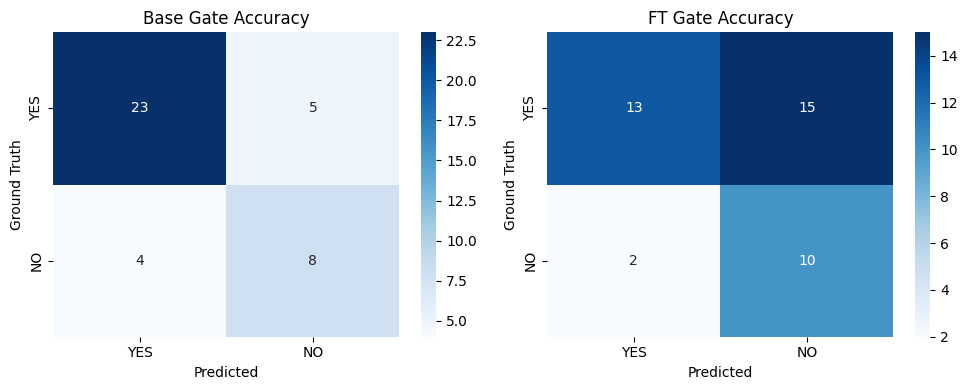

In [10]:
# ============================================================
# CELL 6 — EVAL: COMPLETE PERFORMANCE & GATE AUDIT
# ============================================================
import torch
import re
import os
import json
import evaluate
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from tqdm.auto import tqdm

# --- 1. EVALUATION HELPERS ---
def extract_files(text):
    clean_text = text.replace('**', '')
    match = re.search(r'(?i)Target files:\s*(.*?)(?:\n\s*[-\*•]*\s*Test strategy:|$)', clean_text, re.DOTALL)
    if not match: return set()
    files_block = match.group(1).strip()
    if files_block.lower() in ['none', 'none.', 'n/a']: return set()
    files = re.findall(r'(?m)^\s*[-\*•]\s+([^\n\r]+)', files_block)
    return set(f.strip() for f in files if f.strip() not in ['None', 'None.'])

def extract_classification(text):
    match = re.search(r'REQUIRES_CODE_CHANGE:\s*(YES|NO)', text, re.IGNORECASE)
    return match.group(1).upper() if match else 'UNKNOWN'

def check_structure_score(text):
    is_yes = "REQUIRES_CODE_CHANGE: YES" in text.upper()
    required = [r'REQUIRES_CODE_CHANGE:', r'REASON:']
    if is_yes:
        required += [r'PLAN:', r'-\s*What to change:', r'-\s*Target files:', r'-\s*Test strategy:']
    found = sum(1 for pattern in required if re.search(pattern, text, re.IGNORECASE))
    return found / len(required)

# --- 2. MULTI-PATH GENERATION ENGINE ---
def generate_k_predictions(full_prompt, use_adapter=True, k=1):
    inputs = TOKENIZER(full_prompt, return_tensors='pt').to(model.device)
    with torch.no_grad():
        if use_adapter:
            outputs = model.generate(
                **inputs, max_new_tokens=400, do_sample=(k > 1),
                temperature=0.7 if k > 1 else 1.0, top_p=0.9, num_return_sequences=k
            )
        else:
            with model.disable_adapter():
                outputs = model.generate(
                    **inputs, max_new_tokens=400, do_sample=(k > 1),
                    temperature=0.7 if k > 1 else 1.0, top_p=0.9, num_return_sequences=k
                )
    return [TOKENIZER.decode(out[inputs['input_ids'].shape[1]:], skip_special_tokens=True) for out in outputs]

# --- 3. EVALUATION LOOP ---
eval_samples = test_df.sample(min(40, len(test_df)), random_state=42)
metrics = {'FT': {'recall_1': [], 'recall_3': [], 'recall_6': [], 'structure': [], 'texts': [], 'classes': []},
           'Base': {'recall_1': [], 'recall_3': [], 'recall_6': [], 'structure': [], 'texts': [], 'classes': []}}
gt_classes = []

print(f"Comparing Base vs. Fine-Tuned (k=6) on {len(eval_samples)} test samples...")
for row in tqdm(eval_samples.itertuples(), total=len(eval_samples)):
    gt_output = row.original_output
    gt_files = extract_files(gt_output)
    gt_class = 'YES' if 'REQUIRES_CODE_CHANGE: YES' in gt_output else 'NO'
    gt_classes.append(gt_class)

    for mode in ['FT', 'Base']:
        preds = generate_k_predictions(row.prompt, use_adapter=(mode == 'FT'), k=6)
        top1 = preds[0]

        # Clean 'UNKNOWN' for F1 calculation (treat as NO for safety)
        pred_class = extract_classification(top1)
        metrics[mode]['classes'].append('NO' if pred_class == 'UNKNOWN' else pred_class)
        metrics[mode]['texts'].append(top1)
        metrics[mode]['structure'].append(check_structure_score(top1))

        if gt_class == 'YES' and len(gt_files) > 0:
            pred_file_sets = [extract_files(p) for p in preds]
            metrics[mode]['recall_1'].append(len(gt_files.intersection(pred_file_sets[0])) / len(gt_files))
            metrics[mode]['recall_3'].append(len(gt_files.intersection(set().union(*pred_file_sets[:3]))) / len(gt_files))
            metrics[mode]['recall_6'].append(len(gt_files.intersection(set().union(*pred_file_sets[:6]))) / len(gt_files))

# --- 4. PERSISTENT REPORTING ---
bertscore = evaluate.load("bertscore")
summary_results = []

for mode in ['Base', 'FT']:
    bs = bertscore.compute(predictions=metrics[mode]['texts'], references=[r.original_output for r in eval_samples.itertuples()], lang="en")

    # Calculate Classification Accuracy (F1)
    clf_f1 = f1_score(gt_classes, metrics[mode]['classes'], pos_label='YES')

    summary_results.append({
        'Model': 'Fine-Tuned (AutoBot Planner)' if mode == 'FT' else 'Base (Qwen 2.5 Coder)',
        'Structure Score': f"{sum(metrics[mode]['structure']) / len(metrics[mode]['structure']):.2%}",
        'Classification F1': f"{clf_f1:.4f}",
        'Recall@1': sum(metrics[mode]['recall_1']) / len(metrics[mode]['recall_1']) if metrics[mode]['recall_1'] else 0,
        'Recall@6': sum(metrics[mode]['recall_6']) / len(metrics[mode]['recall_6']) if metrics[mode]['recall_6'] else 0,
        'BERTScore F1': sum(bs['f1']) / len(bs['f1'])
    })

print("\n" + "="*80 + "\nFINAL PERFORMANCE COMPARISON\n" + "="*80)
print(pd.DataFrame(summary_results).to_string(index=False))

# Confusion Matrix for BOTH models for visual proof
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for i, mode in enumerate(['Base', 'FT']):
    cm = confusion_matrix(gt_classes, metrics[mode]['classes'], labels=['YES', 'NO'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['YES', 'NO'], yticklabels=['YES', 'NO'], ax=ax[i])
    ax[i].set_title(f"{mode} Gate Accuracy")
    ax[i].set_ylabel('Ground Truth')
    ax[i].set_xlabel('Predicted')
plt.tight_layout()
plt.show()

with open(os.path.join(ADAPTER_DIR, 'eval_metrics_comparison_final.json'), 'w') as f:
    json.dump(summary_results, f, indent=4)

In [11]:
# ============================================================
# CELL 6B — SAMPLE INFERENCE (The "Vibe Check")
# ============================================================
import random

# 1. Pick 2 random samples from the blind test set
sample_indices = random.sample(range(len(test_df)), 2)

print(f"--- STARTING VIBE CHECK ON {len(sample_indices)} TEST SAMPLES ---\n")

for i, idx in enumerate(sample_indices):
    row = test_df.iloc[idx]

    # Use the 'prompt' we built in Cell 3
    user_prompt = row['prompt']
    ground_truth = row['original_output']

    # Generate the prediction
    inputs = TOKENIZER(user_prompt, return_tensors='pt').to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=300, do_sample=False)
    prediction = TOKENIZER.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

    print(f"=== TEST SAMPLE #{i+1} (Index: {idx}) ===")
    print(f"\n[USER PROMPT/INPUT]:\n{user_prompt}")
    print("\n" + "-"*30)
    print(f"\n[GROUND TRUTH]:\n{ground_truth}")
    print("\n" + "-"*30)
    print(f"\n[AUTOBOT PREDICTION]:\n{prediction}")
    print("\n" + "="*60 + "\n")

--- STARTING VIBE CHECK ON 2 TEST SAMPLES ---

=== TEST SAMPLE #1 (Index: 140) ===

[USER PROMPT/INPUT]:
<|im_start|>system
You are AutoBot Planner. Output STRICT plain text only, no markdown or bold. Use exact fields: REQUIRES_CODE_CHANGE, REASON, and PLAN (for YES). The user message may include --- RETRIEVAL EVIDENCE ---; treat it as context only. Do not output a CONFIDENCE field.<|im_end|>
<|im_start|>user
--- GRAPH RETRIEVAL CONTEXT ---
Historically similar tickets touched these candidate files:
airflow/sensors/base.py
tests/sensors/test_base.py
airflow/migrations/versions/0125_2_6_0_add_poke_number_to_task_reschedule.py
docs/apache-airflow/img/airflow_erd.sha256
airflow/models/taskreschedule.py
docs/apache-airflow/img/airflow_erd.svg

--- RETRIEVAL EVIDENCE ---
retrieval_confidence: MEDIUM (0.53)
sim_top1: 0.893 | sim_top3_mean: 0.89
top1_weight: 2.669 | top2_weight: 1.78 | margin_norm: 0.333
entropy_norm: 0.936 | candidate_count: 6

--- REPO STRUCTURE CONTEXT (TREE-SITTER) ---
ai

In [12]:
# ============================================================
# CELL 7A — PUSH ADAPTER TO HUGGINGFACE HUB
# Since we are using Multi-LoRA on HF Inference endpoints,
# the adapter needs to be hosted on the Hub.
# ============================================================
from huggingface_hub import login
from google.colab import userdata
import os

# Get your WRITE token:
# 1. Go to huggingface.co and create an account (if you don't have one).
# 2. Navigate to Settings -> Access Tokens (or click here: https://huggingface.co/settings/tokens).
# 3. Create a new token and give it "Write" permissions (do not select just "Read").
HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN)

REPO_NAME = 'cyborg1299/autobot-planner-lora-v3'

# Push it!
trainer.model.push_to_hub(REPO_NAME)
TOKENIZER.push_to_hub(REPO_NAME)
print(f"Successfully pushed pure LoRA adapter to https://huggingface.co/{REPO_NAME}")


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          |  557kB / 2.42GB            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp2m01h57b/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

Successfully pushed pure LoRA adapter to https://huggingface.co/cyborg1299/autobot-planner-lora-v3


In [ ]:
# ============================================================
# CELL 7B — PUSH ADAPTER TO HUGGINGFACE HUB (Post-Restart Version)
# ============================================================
from huggingface_hub import login
from google.colab import userdata
import os

# 1. Authenticate
HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN)

# 2. Define Repo
REPO_NAME = 'cyborg1299/autobot-planner-lora-v3'

# 3. Push the 'model' variable directly (which holds your reloaded weights)
# We use save_embedding_layers=True to ensure compatibility with vLLM
model.push_to_hub(REPO_NAME)
TOKENIZER.push_to_hub(REPO_NAME)

print(f"Successfully pushed pure LoRA adapter to https://huggingface.co/{REPO_NAME}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   1%|1         | 3.41MB /  242MB            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpu32lqbr1/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

Successfully pushed pure LoRA adapter to https://huggingface.co/cyborg1299/autobot-planner-lora-v2
